<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/14_SAM3_Stroke_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import userdata
import os
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')


In [ ]:
!mkdir -p /content/drive/MyDrive/MSc_Thesis_Neuroimaging/SAM 3/data/stroke
!kaggle datasets download -d orvile/isles-2022-brain-stoke-dataset -p /content/drive/MyDrive/MSc_Thesis_Neuroimaging/SAM 3/data/stroke --unzip

Dataset URL: https://www.kaggle.com/datasets/orvile/isles-2022-brain-stoke-dataset
License(s): other
100% 1.58G/1.59G [00:10<00:00, 181MB/s]
100% 1.59G/1.59G [00:10<00:00, 166MB/s]
User cancelled operation


In [ ]:
import numpy as np
import nibabel as nib
from PIL import Image
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import torch
import gc

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
def compute_metrics(pred, gt):
    """Calculate segmentation metrics."""
    pred_flat = pred.flatten() > 0.5
    gt_flat = gt.flatten() > 0.5
    tp = np.sum(pred_flat & gt_flat)
    fp = np.sum(pred_flat & ~gt_flat)
    fn = np.sum(~pred_flat & gt_flat)
    tn = np.sum(~pred_flat & ~gt_flat)

    dice = 2 * tp / (2 * tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        'dice': dice,
        'iou': iou,
        'sensitivity': sens,
        'specificity': spec,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    }

In [ ]:
def normalize_mri(img):
    """Normalize MRI to [0, 1] range."""
    img_min, img_max = img.min(), img.max()
    return (img - img_min) / (img_max - img_min + 1e-8)

In [ ]:
def safe_sam3_inference(processor, img, prompt, debug=False):
    """Safe SAM3 inference with correct API."""
    try:
        if img.mode != 'RGB':
            img = img.convert('RGB')

        inference_state = processor.set_image(img)

        output = processor.set_text_prompt(prompt, inference_state)

        masks = output.get("masks", torch.tensor([]))
        scores = output.get("scores", torch.tensor([]))

        if debug:
            print(f"      Prompt '{prompt}': {len(masks)} masks, scores={scores.tolist() if len(scores) > 0 else []}")

        if len(masks) == 0 or len(scores) == 0:
            return None, 0.0, 0

        best_idx = torch.argmax(scores)
        best_mask = masks[best_idx].cpu().numpy().squeeze()
        best_score = scores[best_idx].item()

        torch.cuda.empty_cache()

        return best_mask, best_score, len(masks)
    except Exception as e:
        if debug:
            print(f"      ⚠️  Error with '{prompt}': {e}")
        torch.cuda.empty_cache()
        return None, 0.0, 0



In [ ]:
def load_stroke_case(case_name, base_path):
    from scipy.ndimage import zoom

    flair = mask = None

    # Find FLAIR image
    flair_path = base_path / case_name / "ses-0001" / "anat"
    flair_files = list(flair_path.glob("*_FLAIR.nii*"))
    if flair_files:
        flair_nii = nib.load(flair_files[0])
        flair = flair_nii.get_fdata()

    # Find mask in derivatives
    mask_path = base_path / "derivatives" / case_name / "ses-0001"
    mask_files = list(mask_path.glob("*_msk.nii*"))
    if mask_files:
        mask_nii = nib.load(mask_files[0])
        mask = mask_nii.get_fdata()

    if flair is None or mask is None:
        return None, None

    # Check if dimensions match
    if flair.shape != mask.shape:
        # Resample mask to FLAIR space using zoom
        zoom_factors = [flair.shape[i] / mask.shape[i] for i in range(3)]
        mask_resampled = zoom(mask, zoom_factors, order=0)  # Nearest neighbor for binary mask

        # Ensure exact shape match (zoom can be off by 1 voxel)
        if mask_resampled.shape != flair.shape:
            # Crop or pad to match
            result = np.zeros(flair.shape)
            slices = tuple(slice(0, min(mask_resampled.shape[i], flair.shape[i])) for i in range(3))
            result[slices] = mask_resampled[slices]
            mask_resampled = result

        return flair, mask_resampled

    return flair, mask

In [ ]:
def plot_stroke_comparison(flair_slice, gt_mask, sam3_mask, score, case_name,
                           slice_idx, dice, save_path):
    """4-panel stroke lesion visualization."""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. FLAIR input
    axes[0,0].imshow(flair_slice, cmap='gray')
    axes[0,0].set_title(f'{case_name} slice {slice_idx}\nFLAIR/T2 Input',
                       fontsize=12, fontweight='bold')
    axes[0,0].axis('off')

    # 2. Ground Truth lesion
    axes[0,1].imshow(gt_mask, cmap='Reds', alpha=0.8, vmin=0, vmax=1)
    axes[0,1].set_title(f'Expert Ground Truth\nLesion voxels: {gt_mask.sum():,.0f}',
                       fontsize=12, fontweight='bold')
    axes[0,1].axis('off')

    # 3. SAM3 Prediction
    axes[1,0].imshow(sam3_mask > 0.5, cmap='Greens', alpha=0.8)
    axes[1,0].set_title(f'SAM3 Prediction\nScore: {score:.3f} | Voxels: {(sam3_mask > 0.5).sum():,.0f}',
                       fontsize=12, fontweight='bold')
    axes[1,0].axis('off')

    # 4. Overlay: Red=GT, Green=SAM3, Yellow=Overlap
    overlay = np.stack([flair_slice, flair_slice, flair_slice], axis=-1)

    gt_binary = gt_mask > 0
    pred_binary = sam3_mask > 0.5

    # Red for GT only
    overlay[gt_binary & ~pred_binary, 0] = 1.0
    overlay[gt_binary & ~pred_binary, 1] = 0.0
    overlay[gt_binary & ~pred_binary, 2] = 0.0

    # Green for SAM3 only
    overlay[~gt_binary & pred_binary, 0] = 0.0
    overlay[~gt_binary & pred_binary, 1] = 1.0
    overlay[~gt_binary & pred_binary, 2] = 0.0

    # Yellow for overlap
    overlap = gt_binary & pred_binary
    overlay[overlap, 0] = 1.0
    overlay[overlap, 1] = 1.0
    overlay[overlap, 2] = 0.0

    axes[1,1].imshow(overlay)
    axes[1,1].set_title(f'OVERLAY: Red=GT | Green=SAM3 | Yellow=Match\nDice: {dice:.3f}',
                       fontsize=14, fontweight='bold', pad=20)
    axes[1,1].axis('off')

    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

In [ ]:
def evaluate_stroke_dataset(processor, max_cases=20):
    """Evaluate SAM3 on stroke lesion segmentation."""

    dataset_path = Path("/content/drive/MyDrive/MSc_Thesis_Neuroimaging/SAM 3/data/stroke/ISLES-2022")

    case_dirs = sorted(dataset_path.glob("sub-strokecase*"))
    case_dirs = case_dirs[:max_cases]

    results = []
    plot_paths = []

    plot_dir = dataset_path / "sam3_results"
    plot_dir.mkdir(exist_ok=True, parents=True)

    print(f"🧠 Evaluating SAM3 on {len(case_dirs)} ISLES-2022 stroke cases...\n")

    for case_dir in tqdm(case_dirs, desc="Processing"):
        case_name = case_dir.name

        # Load case
        flair, mask = load_stroke_case(case_name, dataset_path)

        if flair is None or mask is None:
            print(f"  ⚠️  Skipping {case_name}: failed to load (flair={flair is not None}, mask={mask is not None})")
            continue

        # Find slice with largest lesion
        if len(mask.shape) == 3:
            lesion_volumes = mask.sum(axis=(0,1))

            # Safety check for slice index
            if len(lesion_volumes) == 0:
                print(f"  ⚠️  Skipping {case_name}: empty mask volume")
                continue

            best_slice = np.argmax(lesion_volumes)

            # Ensure slice index is valid for both mask and flair
            max_slice = min(mask.shape[2], flair.shape[2]) - 1
            best_slice = min(best_slice, max_slice)

            gt_slice = mask[:, :, best_slice] > 0
            flair_slice = flair[:, :, best_slice]
        else:
            # 2D case
            gt_slice = mask > 0
            flair_slice = flair
            best_slice = 0

        if gt_slice.sum() < 20:
            print(f"  ⚠️  Skipping {case_name}: lesion too small ({gt_slice.sum()} voxels)")
            continue

        # Prepare FLAIR image
        flair_normalized = normalize_mri(flair_slice)
        flair_rgb = np.repeat(flair_normalized[:, :, np.newaxis], 3, axis=2)
        flair_rgb = (flair_rgb * 255).astype(np.uint8)
        img = Image.fromarray(flair_rgb)

        # Multi-prompt SAM3 inference
        prompts = [
            "stroke lesion",
            "brain lesion",
            "ischemic stroke",
            "white matter hyperintensity",
            "abnormal brain tissue"
        ]

        best_dice = 0
        best_mask = None
        best_score = 0
        best_prompt = ""

        # Debug first case
        debug_mode = (case_name == "sub-strokecase0001")
        if debug_mode:
            print(f"\n  🔍 Debug info for {case_name}:")
            print(f"     FLAIR slice: {flair_slice.shape}, range=[{flair_slice.min():.2f}, {flair_slice.max():.2f}]")
            print(f"     GT mask: {gt_slice.sum()} voxels")
            print(f"     Image for SAM3: {img.size}, mode={img.mode}")

        for prompt in prompts:
            pred_mask, score, n_masks = safe_sam3_inference(processor, img, prompt, debug=debug_mode)

            if pred_mask is not None:
                metrics = compute_metrics(pred_mask, gt_slice)
                if metrics['dice'] > best_dice:
                    best_dice = metrics['dice']
                    best_mask = pred_mask
                    best_score = score
                    best_prompt = prompt

        if best_mask is None:
            print(f"  ⚠️  {case_name}: SAM3 failed on all prompts")
            continue

        # Create visualization
        plot_filename = f"{case_name}_s{best_slice}_dice{best_dice:.3f}.png"
        plot_path = plot_dir / plot_filename

        plot_stroke_comparison(flair_normalized, gt_slice, best_mask,
                              best_score, case_name, best_slice,
                              best_dice, plot_path)

        plot_paths.append(str(plot_path))

        # Save metrics
        metrics = compute_metrics(best_mask, gt_slice)
        metrics.update({
            'case': case_name,
            'slice': best_slice,
            'score': best_score,
            'prompt': best_prompt,
            'gt_voxels': int(gt_slice.sum()),
            'pred_voxels': int((best_mask > 0.5).sum()),
            'plot_path': str(plot_path)
        })
        results.append(metrics)

    # Results summary
    if len(results) == 0:
        print("\n❌ No valid results - all cases failed!")
        return None

    results_df = pd.DataFrame(results)

    print("\n" + "="*80)
    print("📊 ISLES-2022 SAM3 Zero-Shot Results:")
    print("="*80)
    print(f"\nCases processed: {len(results)}/{len(case_dirs)}")
    print(f"\nDice Score:       {results_df['dice'].mean():.3f} ± {results_df['dice'].std():.3f}")
    print(f"IoU:              {results_df['iou'].mean():.3f} ± {results_df['iou'].std():.3f}")
    print(f"Sensitivity:      {results_df['sensitivity'].mean():.3f} ± {results_df['sensitivity'].std():.3f}")
    print(f"Specificity:      {results_df['specificity'].mean():.3f} ± {results_df['specificity'].std():.3f}")
    print(f"Best prompt:      {results_df['prompt'].mode().iloc[0] if len(results_df) > 0 else 'N/A'}")

    print("\n📈 Comparison to ISLES-2022 Challenge Winners:")
    print("  ISLES-2022 Winner (nnU-Net):  0.58 Dice")
    print(f"  Your SAM3 (zero-shot):        {results_df['dice'].mean():.3f} Dice")

    # Create gallery
    n_plots = min(16, len(plot_paths))
    if n_plots > 0:
        cols = 4
        rows = (n_plots + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
        if rows == 1:
            axes = [axes] if cols == 1 else axes
        else:
            axes = axes.flatten()

        for i, plot_path in enumerate(plot_paths[:n_plots]):
            img = plt.imread(plot_path)
            axes[i].imshow(img)
            axes[i].set_title(Path(plot_path).stem.replace('_', ' '), fontsize=8)
            axes[i].axis('off')

        for i in range(n_plots, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        gallery_path = plot_dir / "isles_gallery.png"
        plt.savefig(gallery_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✅ Gallery saved: {gallery_path}")

    # Save results
    csv_path = plot_dir / "isles_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"✅ Results saved: {csv_path}")

    return results_df

In [ ]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"  > /dev/null
%cd /content

!pip install -q supervision jupyter_bbox_widget  > /dev/null


Cloning into 'sam3'...
remote: Enumerating objects: 894, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 894 (delta 91), reused 54 (delta 54), pack-reused 684 (from 2)
Receiving objects: 100% (894/894), 59.43 MiB | 35.06 MiB/s, done.
Resolving deltas: 100% (190/190), done.
/content/sam3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but 

In [ ]:
!pip install triton decord  > /dev/null

In [ ]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [ ]:
import sam3
from sam3.sam3 import build_sam3_image_model
import os

bpe_path = f"/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"

In [ ]:
from sam3.model.sam3_image_processor import Sam3Processor
model = build_sam3_image_model(bpe_path=bpe_path)
processor = Sam3Processor(model, confidence_threshold=0.5)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

🧠 Evaluating SAM3 on 100 ISLES-2022 stroke cases...



Processing:   0%|          | 0/100 [00:00<?, ?it/s]


  🔍 Debug info for sub-strokecase0001:
     FLAIR slice: (281, 352), range=[0.00, 2028.21]
     GT mask: 432 voxels
     Image for SAM3: (352, 281), mode=RGB
      Prompt 'stroke lesion': 0 masks, scores=[]
      Prompt 'brain lesion': 0 masks, scores=[]
      Prompt 'ischemic stroke': 0 masks, scores=[]
      Prompt 'white matter hyperintensity': 0 masks, scores=[]


Processing:   1%|          | 1/100 [00:11<18:12, 11.04s/it]

      Prompt 'abnormal brain tissue': 0 masks, scores=[]
  ⚠️  sub-strokecase0001: SAM3 failed on all prompts


...

  ⚠️  sub-strokecase0096: SAM3 failed on all prompts


Processing:  97%|█████████▋| 97/100 [22:12<00:42, 14.22s/it]

  ⚠️  sub-strokecase0097: SAM3 failed on all prompts


Processing: 100%|██████████| 100/100 [22:56<00:00, 13.77s/it]

  ⚠️  sub-strokecase0100: SAM3 failed on all prompts

📊 ISLES-2022 SAM3 Zero-Shot Results:

Cases processed: 25/100

Dice Score:       0.492 ± 0.267
IoU:              0.366 ± 0.237
Sensitivity:      0.487 ± 0.298
Specificity:      0.996 ± 0.006
Best prompt:      stroke lesion

📈 Comparison to ISLES-2022 Challenge Winners:
  ISLES-2022 Winner (nnU-Net):  0.58 Dice
  Your SAM3 (zero-shot):        0.492 Dice


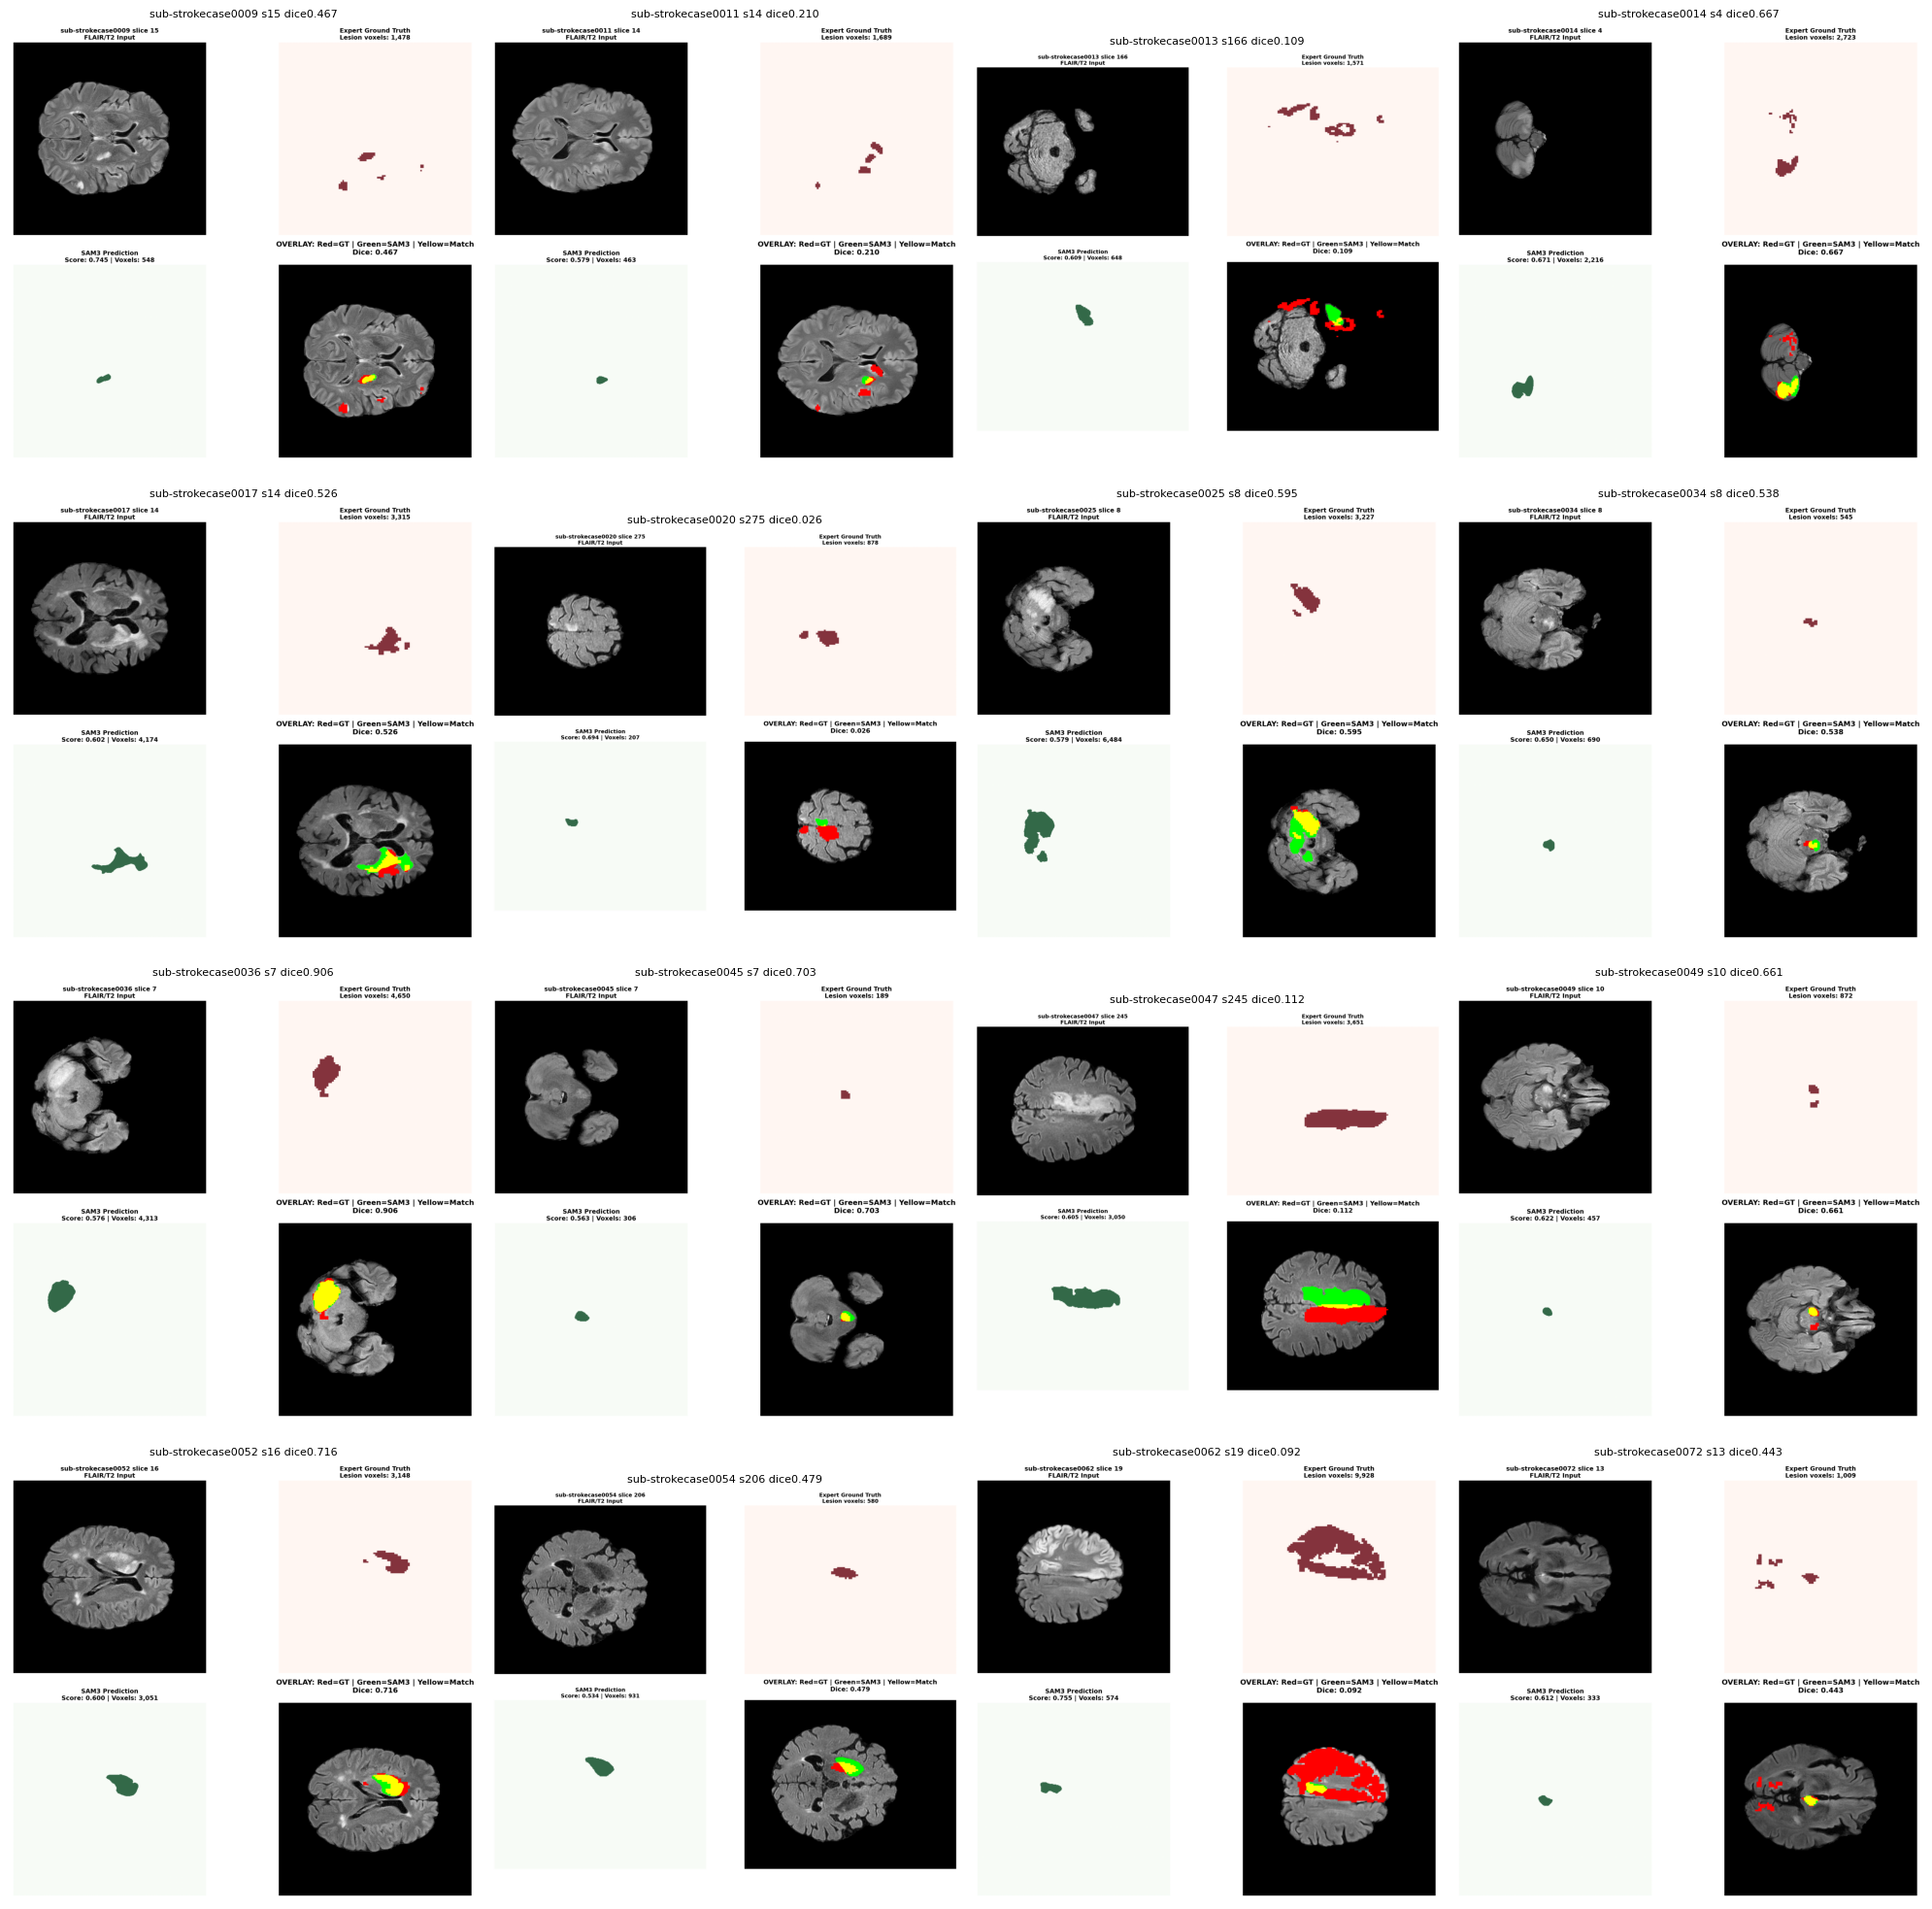


✅ Gallery saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/SAM 3/data/stroke/ISLES-2022/sam3_results/isles_gallery.png
✅ Results saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/SAM 3/data/stroke/ISLES-2022/sam3_results/isles_results.csv


In [ ]:
isles22_results = evaluate_stroke_dataset(processor, max_cases=100)


 Detailed Results:
                  case  slice      dice       iou  sensitivity  \
0   sub-strokecase0009     15  0.466930  0.304572     0.320027   
1   sub-strokecase0011     14  0.210037  0.117342     0.133807   
2   sub-strokecase0013    166  0.109058  0.057674     0.077021   
3   sub-strokecase0014      4  0.666937  0.500304     0.604848   
4   sub-strokecase0017     14  0.525571  0.356457     0.593665   
5   sub-strokecase0020    275  0.025806  0.013072     0.015945   
6   sub-strokecase0025      8  0.594995  0.423483     0.895259   
7   sub-strokecase0034      8  0.537652  0.367663     0.609174   
8   sub-strokecase0036      7  0.906170  0.828437     0.873333   
9   sub-strokecase0045      7  0.703030  0.542056     0.920635   
10  sub-strokecase0047    245  0.111625  0.059112     0.102438   
11  sub-strokecase0049     10  0.660647  0.493258     0.503440   
12  sub-strokecase0052     16  0.715599  0.557146     0.704574   
13  sub-strokecase0054    206  0.479153  0.315057     0.

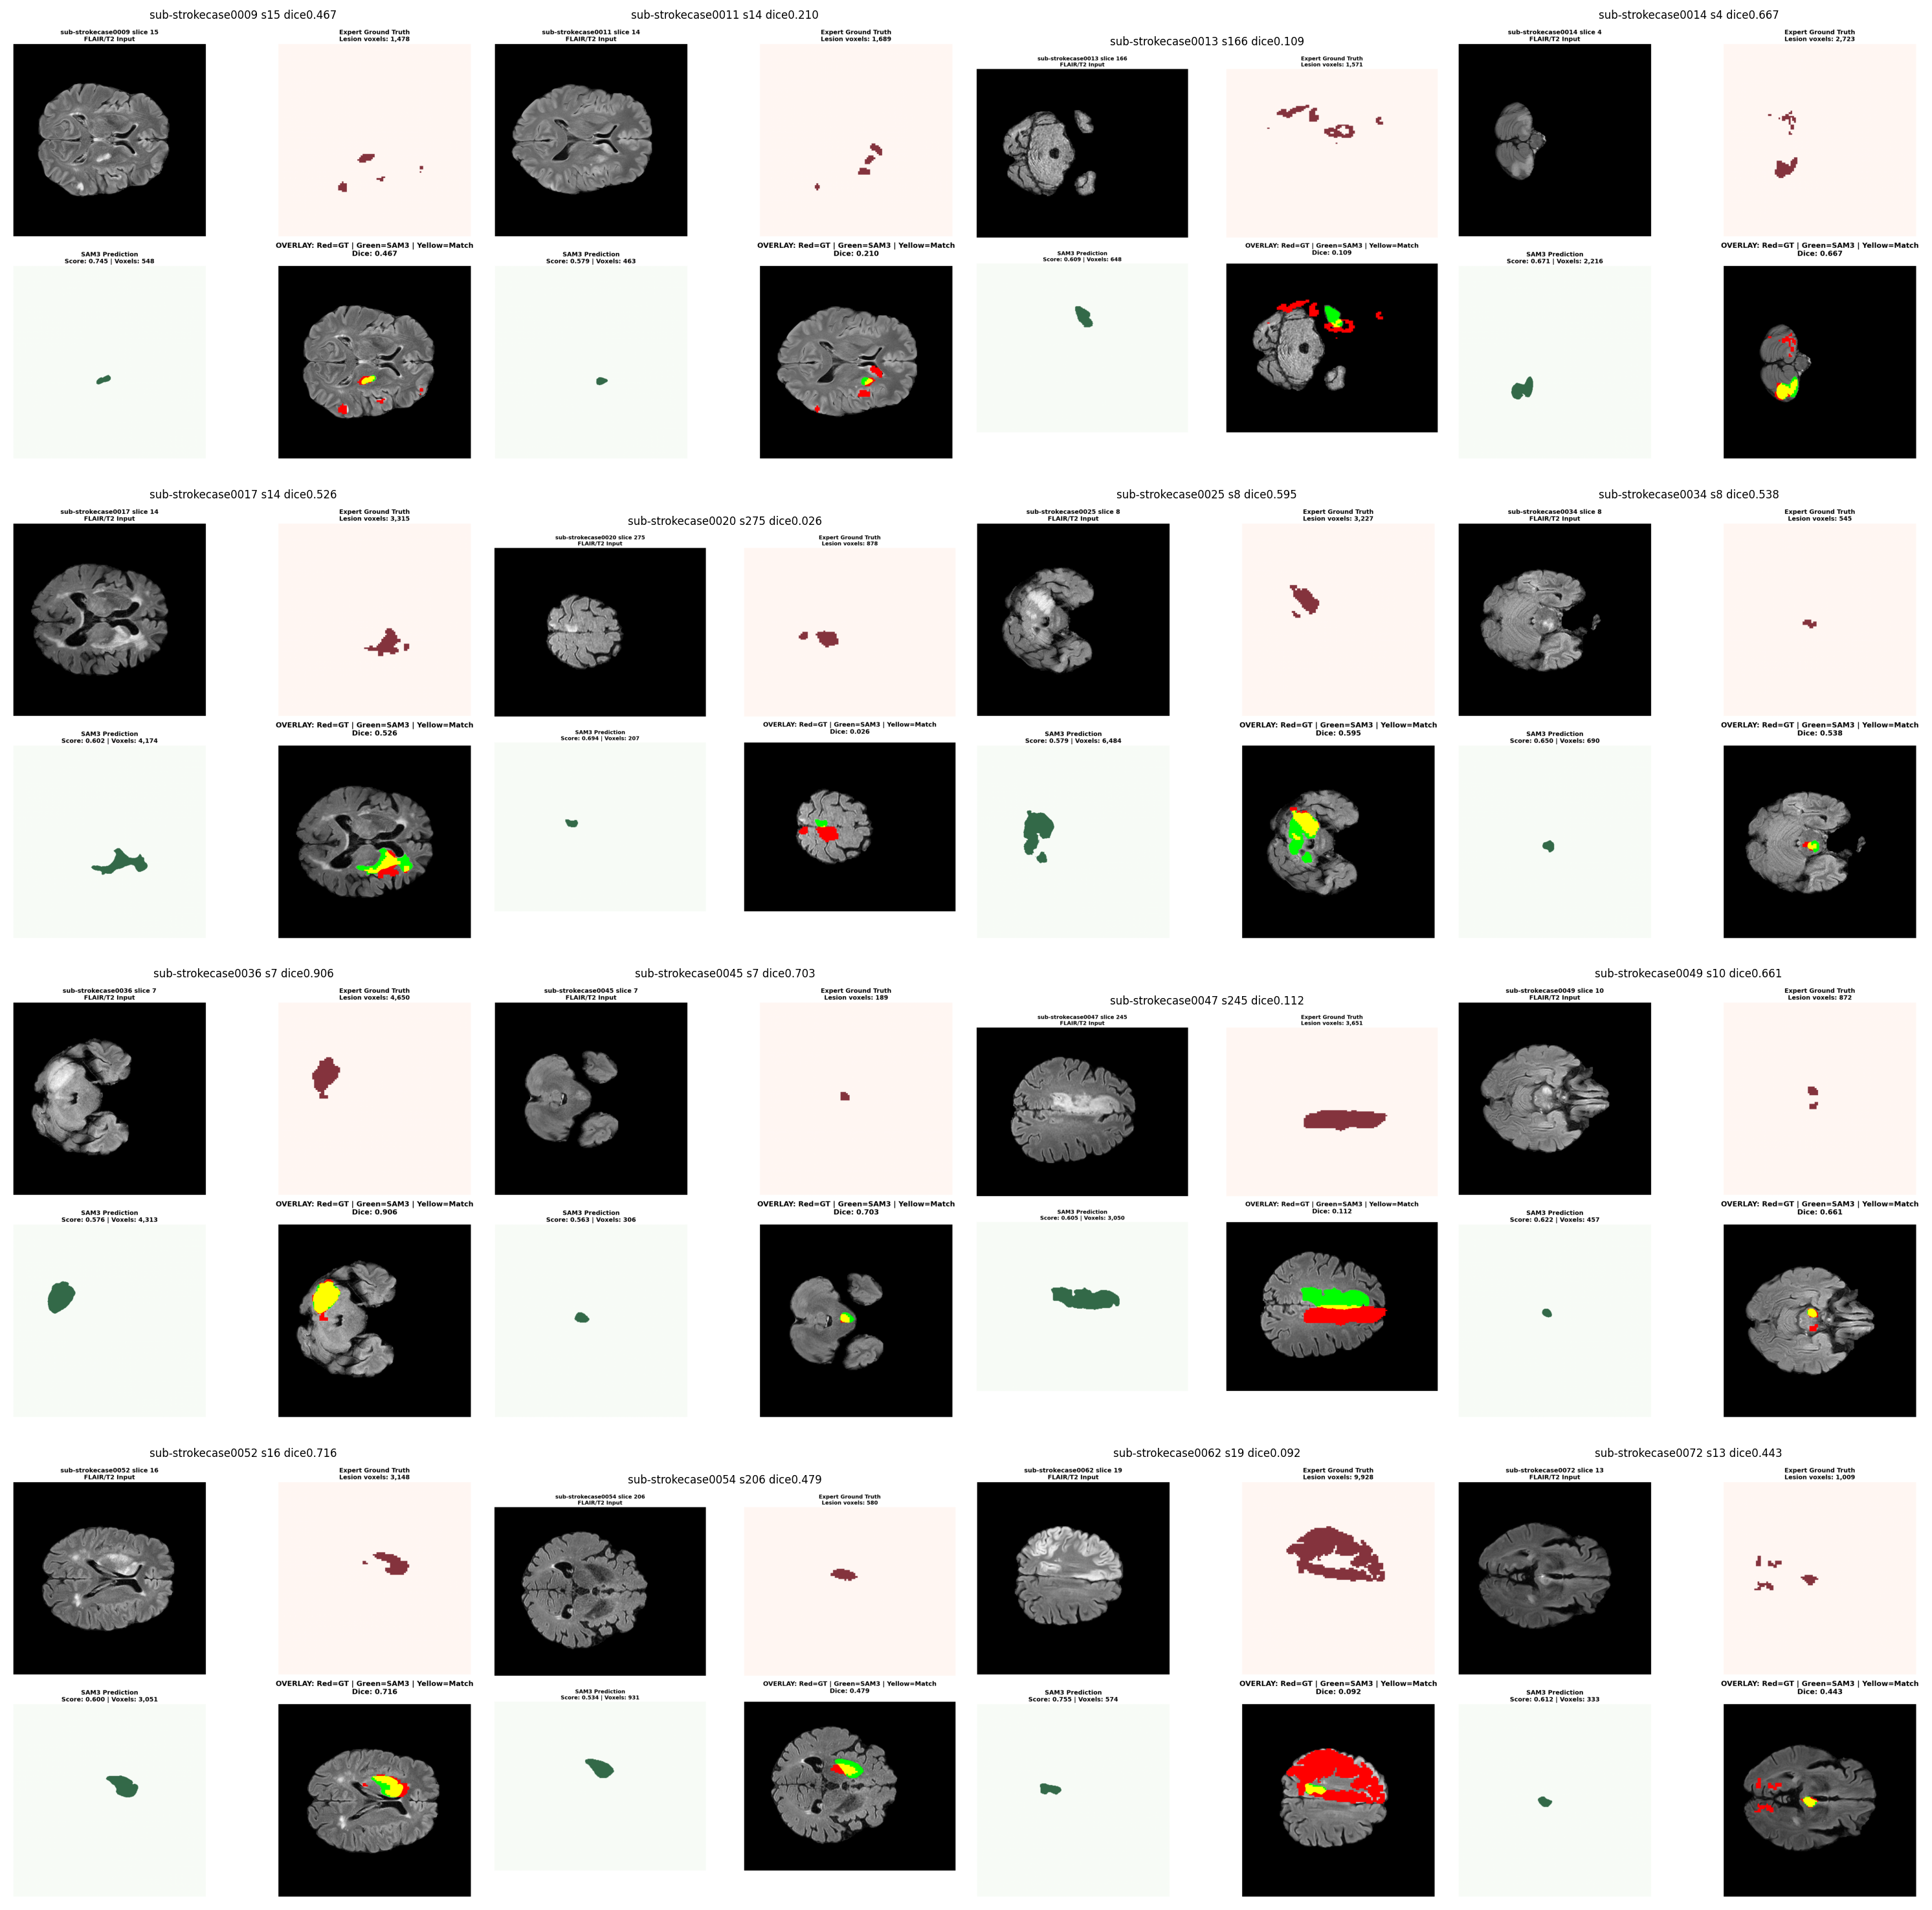

In [ ]:
print("\n Detailed Results:")
print(isles22_results[['case', 'slice', 'dice', 'iou', 'sensitivity', 'prompt', 'gt_voxels', 'pred_voxels']])

print(f"\n Successful cases: {len(isles22_results)}/100")
print(f" Failed cases: {100 - len(isles22_results)}/100")

print("\n Best performing case:")
best_idx = isles22_results['dice'].idxmax()
print(f"  {isles22_results.loc[best_idx, 'case']}: Dice={isles22_results.loc[best_idx, 'dice']:.3f}")

print("\n Worst performing case:")
worst_idx = isles22_results['dice'].idxmin()
print(f"  {isles22_results.loc[worst_idx, 'case']}: Dice={isles22_results.loc[worst_idx, 'dice']:.3f}")

gallery_path = Path("/content/drive/MyDrive/MSc_Thesis_Neuroimaging/SAM 3/data/stroke/ISLES-2022/sam3_results/isles_gallery.png")
if gallery_path.exists():
    from IPython.display import Image as IPImage, display
    print("\n Results Gallery:")
    display(IPImage(filename=str(gallery_path)))